# **Ejercicio 1. Análisis Exploratorio de Datos**

# *Planteamiento*

Considere la serie de tiempo asociada con las acciones de Bitcoin (ver https://github.com/lihkir/Data/blob/main/btc_15m_data_2018_to_2025.csv importe directamente con el link y pd.read_csv). Realice un Análisis Exploratorio de Datos (EDA) considerando cada una de las metodología abordadas durante el curso. Es crucial que en todos los ejercicios de la presente evaluación, cada figura descriptiva, tabla o resumen de resultados, cuente con su respectiva interpretación

Utilice el conjunto de datos asociados con el precio de Bitcoin. Considere para las predicciones con modelos de series de tiempo, la columna Price

Identifique si existen datos faltantes y realice su imputación usando alguna de las técnicas básicas estudiadas durante el curso.

Realice un grafico de velas utilizando la librería Plotly para la serie de tiempo (columna Price). Realice también un histograma con Plotly para representar el volumen tradeado diariamente (Volume)

Realice graficos de subseries considerando agrupación por semana, mes y año. Utilice graficos de series de tiempo y boxplots para analizar estas subseries.

Estudie estacionariedad de la serie de tiempo usando la ACF estudiada durante el curso, así como también los respectivos test estadísticos tales como Ljung-Box y Dickey Fuller. Aplique además las transformaciones necesarias para convertir la serie de tiempo en estacionaria.

Mediante agregación por grupos analice el comportamiento de la media y desviación estándar, agrupando por semanas, días, meses. Además, para estas agrupaciones, calcule estadísticos móviles. Dibuje la distribución de frecuencias para diferentes lags como se realizó en las notas del curso.

Aplique las medias móviles $\widehat{M}_t^{(2)}$, $\widehat{M}_t^{(2)}(t,t+1)$, $\widehat{M}_t^{(4)}(t,t+1)$, $\widehat{M}_t^{(3)}$, y $\widehat{M}_t^{(3)}(t-1,t+1)$  a la serie del precio de cierre de BTC-USD. Posteriormente, úselas para remover tendencia y aplique la prueba de Dickey-Fuller y Ljung-Box para verificar si se logró estacionariedad.


- Realice descomposición de la serie temporal del precio de cierre de BTC-USD usando **medias móviles** y además usando la librería **statsmodels.tsa**. Verifique al final independencia de los residuos mediante la prueba de **Ljung-Box**.

(II) Repita el análisis anterior para las series de tiempo de: retorno acumulado diario y volatilidad, para diferentes ventanas. Para esto tenga en cuenta las siguientes definiciones e implemente manualmente las funciones que definen cada serie de tiempo  

- **Retorno acumulado diario** $\{A_t\}_{t=1}^{T}$ donde  

$$
A_t = \sum_{j=1}^{t} R_j, \quad \text{con} \quad R_t = \frac{P_t - P_{t-1}}{P_{t-1}},
$$  

donde $P_t, t=1,2,\dots,T$ es la columna *Price* en el dataset de Bitcoin y $T$ es el tiempo final.

- **La volatilidad** $\{\sigma_t\}_{t=1}^{T}$ es la desviación estándar de los retornos diarios  

$$
\sigma = \text{std}(R_1, R_2, \dots, R_{\omega}) \quad \text{donde} \quad \omega = 7, 14, 21, 28,
\tag{2}
$$  

siendo $\omega$ el número de retornos diarios considerados para calcular la desviación estándar  

$$
\text{std}(R_1, R_2, \dots, R_{\omega}) = \sqrt{\frac{1}{\omega - 1} \sum_{t=1}^{\omega} (R_t - \mu)}, \quad \mu = \frac{1}{\omega} \sum_{t=1}^{\omega} R_t,
\tag{3}
$$  

obtenida por ventanas móviles de longitud $\omega$, donde $\omega$ está dado en días, y esta desviación es calculada sobre la serie de retornos diarios. Para cada ventana $\omega$ repita el ítem (I).


# *Solución*

## 1.1 Cargue y preparación de datos

In [162]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')
 
# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

In [163]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(4999, 6)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4999 entries, 2010-07-18 to 2024-03-24
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     4999 non-null   float64
 1   Open      4999 non-null   float64
 2   High      4999 non-null   float64
 3   Low       4999 non-null   float64
 4   Vol.      4993 non-null   float64
 5   Change %  4999 non-null   float64
dtypes: float64(6)
memory usage: 273.4 KB
None
Price       0
Open        0
High        0
Low         0
Vol.        6
Change %    0
dtype: int64


In [164]:
print(df.head())

            Price  Open  High  Low    Vol.  Change %
Date                                                
2010-07-18    0.1   0.0   0.1  0.1    80.0       0.0
2010-07-19    0.1   0.1   0.1  0.1   570.0       0.0
2010-07-20    0.1   0.1   0.1  0.1   260.0       0.0
2010-07-21    0.1   0.1   0.1  0.1   580.0       0.0
2010-07-22    0.1   0.1   0.1  0.1  2160.0       0.0


In [165]:
print(df[df.isnull().any(axis=1)])

            Price  Open  High   Low  Vol.  Change %
Date                                               
2011-06-20   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-21   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-22   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-23   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-24   17.5  17.5  17.5  17.5   NaN       0.0
2011-06-25   17.5  17.5  17.5  17.5   NaN       0.0


In [166]:
# Contar valores nulos en cada columna
valores_faltantes = df.isnull().sum()

# Filtrar solo las columnas que tienen valores nulos
valores_faltantes = valores_faltantes[valores_faltantes > 0]

# Mostrar resultado
print("Valores faltantes por columna:")
print(valores_faltantes)

Valores faltantes por columna:
Vol.    6
dtype: int64


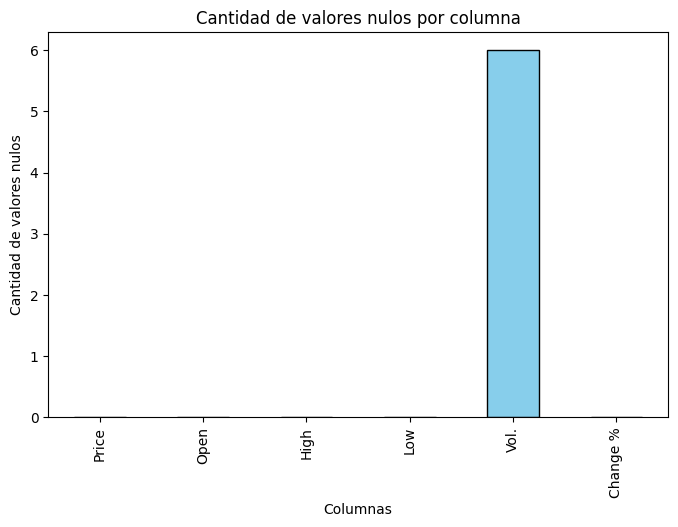

In [167]:
# Gráfica de Barras (Conteo de Valores Faltantes)

df.isnull().sum().plot(kind='bar', color='skyblue', figsize=(8, 5), edgecolor='black')

# Título y etiquetas
plt.title("Cantidad de valores nulos por columna")
plt.xlabel("Columnas")
plt.ylabel("Cantidad de valores nulos")
plt.show()

En la primera parte de este análisis observamos un conjunto de datos con siete columnas que contienen variables relacionadas con el Bitcoin. El total de observaciones es 4,999, y se identificaron seis datos faltantes en la columna "Volumen".

In [168]:
# Contar valores faltantes por columna
missing_values = df.isnull().sum()

# Mostrar solo columnas con valores faltantes
missing_values = missing_values[missing_values > 0]

# Imprimir el resultado
print(missing_values)

Vol.    6
dtype: int64


In [169]:
# Imputación combinada: Imputación por propagación hacia adelante y hacia atras (ffill + bfill).
df.fillna(method='bfill', inplace=True)  # Usa el siguiente valor disponible
df.fillna(method='ffill', inplace=True)  # Usa el valor anterior si sigue habiendo nulos

In [170]:
# Verificar si los valores faltantes fueron imputados
missing_values_after = df['Price'].isna().sum()
print(f"Número de valores faltantes después de la imputación: {missing_values_after}")

Número de valores faltantes después de la imputación: 0


## 1.2 Visualización y análisis descriptivo

In [171]:
# Graficar la serie de precios
import plotly.express as px  
graph_price = px.line(df, x=df.index, y='Price', title='Serie Temporal del Precio de Bitcoin')
graph_price.show()

En la visualización del análisis descriptivo, la serie de tiempo muestra un inicio con valores muy bajos en comparación con el crecimiento exponencial que se observa más adelante. Inicialmente, el precio del Bitcoin comienza en 0.1 y se mantiene en niveles bajos durante aproximadamente la mitad del período analizado. Posteriormente, se evidencia una tendencia creciente que culmina con un valor cercano a $73,000 hacia el final de la serie.

In [172]:
# Gráfico de velas con Plotly
import plotly.graph_objects as go
fig_candlestick = go.Figure(data=[
    go.Candlestick(x=df.index,
                   open=df['Open'], high=df['High'],
                   low=df['Low'], close=df['Price'])
])
fig_candlestick.update_layout(title='Gráfico de Velas de Bitcoin')
fig_candlestick.show()

Se generó un gráfico de velas interactivo que permite hacer zoom y observar el valor diario del Bitcoin. Esta representación facilita el análisis de las fluctuaciones diarias y permite ubicar cualquier observación dentro del período analizado.

In [173]:
# Histograma del Volumen Tradeado

# Cargar los datos de Bitcoin en el DataFrame
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Crear el histograma del volumen tradeado diariamente
fig = px.histogram(df, x="Vol.", title="Histograma de Frecuencia del Volumen Tradeado Diariamente")

# Configurar el color de las barras
fig.update_traces(marker_color='gray')  # Color gris

# Cambiar el fondo a blanco
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')

# Configurar los ejes
fig.update_xaxes(title_text="Volumen Tradeado")  # Eje X con el volumen tradeado
fig.update_yaxes(title_text="Frecuencia")  # Eje Y con la frecuencia

# Mostrar la gráfica
fig.show()

Posteriormente, se construyó un histograma para representar la distribución del volumen de transacciones de Bitcoin a nivel diario, donde el eje X corresponde al volumen y el eje Y a la frecuencia de cada intervalo de volumen. El objetivo de este histograma es obtener una representación visual de cómo se distribuye el volumen de transacciones de Bitcoin a lo largo del tiempo, permitiendo identificar patrones o anomalías en los datos.

El comportamiento observado en las barras del histograma, especialmente su dispersión, puede explicarse por varios factores relacionados con los datos y la naturaleza del mercado de Bitcoin. Las barras del histograma muestran una gran dispersión debido a la alta volatilidad y variabilidad del mercado de Bitcoin. El volumen de transacciones puede fluctuar significativamente en períodos muy cortos, lo que provoca una gran cantidad de días con volúmenes extremos. Esta variabilidad distorsiona la distribución de los datos, resultando en una forma platicúrtica, caracterizada por colas gruesas y una amplia dispersión en relación con la media.


In [174]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# --- Paso 1: Preparar el DataFrame ---
# Se asume que df ya está cargado y contiene las columnas "Price", "Open", "High", "Low"
# Convertir "Price" y otras columnas a numérico (quitando comas si las hay)
df['Price'] = pd.to_numeric(df['Price'].astype(str).str.replace(',', ''), errors='coerce')
df['Open'] = pd.to_numeric(df['Open'].astype(str).str.replace(',', ''), errors='coerce')
df['High'] = pd.to_numeric(df['High'].astype(str).str.replace(',', ''), errors='coerce')
df['Low']  = pd.to_numeric(df['Low'].astype(str).str.replace(',', ''), errors='coerce')

# --- Paso 2: Crear series de tiempo agregadas por semana, mes y año ---
# Se asume que df ya tiene "Date" como índice
df_ts = df.copy()

# Agregación semanal, mensual y anual (usando la media de Price)
weekly_series  = df_ts['Price'].resample('W').mean()
monthly_series = df_ts['Price'].resample('M').mean()
annual_series  = df_ts['Price'].resample('A').mean()

# --- Paso 3: Gráficos de series de tiempo ---

# Gráfico de series de tiempo semanal
fig_week = go.Figure()
fig_week.add_trace(go.Scatter(x=weekly_series.index, y=weekly_series.values,
                              mode='lines', name='Semanal'))
fig_week.update_layout(title='Serie de Tiempo - Agregación Semanal',
                       xaxis_title='Fecha', yaxis_title='Precio')
fig_week.show()

# Gráfico de series de tiempo mensual
fig_month = go.Figure()
fig_month.add_trace(go.Scatter(x=monthly_series.index, y=monthly_series.values,
                               mode='lines', name='Mensual'))
fig_month.update_layout(title='Serie de Tiempo - Agregación Mensual',
                        xaxis_title='Fecha', yaxis_title='Precio')
fig_month.show()

# Gráfico de series de tiempo anual
fig_year = go.Figure()
fig_year.add_trace(go.Scatter(x=annual_series.index, y=annual_series.values,
                              mode='lines', name='Anual'))
fig_year.update_layout(title='Serie de Tiempo - Agregación Anual',
                       xaxis_title='Fecha', yaxis_title='Precio')
fig_year.show()

Al analizar las series de tiempo del precio de Bitcoin agregadas en diferentes frecuencias (semanal, mensual y anual), se observan las siguientes características:

Agregación semanal: La serie mantiene una forma y tendencia similares a la observada en los datos diarios, reflejando las fluctuaciones detalladas del precio de Bitcoin.

Agregación mensual: La serie presenta una suavización de las fluctuaciones, lo que facilita la identificación de tendencias generales y patrones más amplios en el comportamiento del precio.

Agregación anual: La serie muestra una tendencia más estable, con menos fluctuaciones visibles. Se destaca una fase inicial con valores cercanos a cero en los primeros años, seguida de un incremento notable en la segunda mitad del período analizado.

In [175]:
# Conviersión de todas las columnas de tipo Period a str antes de graficar:

df['Year'] = df.index.to_period('Y').astype(str)
df['Month'] = df.index.to_period('M').astype(str)  # Convertir 'Month' a string
df['Week'] = df.index.to_period('W').astype(str)   # Convertir 'Week' a string

# Gráficos de subseries por semana, mes y año.
fig_weekly = px.box(df, x='Week', y='Price', title='Distribución del Precio por Semana')
fig_weekly.show()

fig_monthly = px.box(df, x='Month', y='Price', title='Distribución del Precio por Mes')
fig_monthly.show()

fig_yearly = px.box(df, x='Year', y='Price', title='Distribución del Precio por Año')
fig_yearly.show()

En cuanto a los diagramas de caja (box plots) agrupados por semana, mes y año, se pueden realizar las siguientes observaciones:

Box plots semanales: Muestran una distribución regular de los precios, permitiendo identificar la variabilidad y posibles valores atípicos en intervalos cortos de tiempo.

Box plots mensuales: Ofrecen una visión más consolidada de la dispersión de los precios dentro de cada mes, facilitando la comparación entre diferentes períodos mensuales.

Box plots anuales: Reflejan la tendencia general observada en la serie anual, destacando la estabilidad en los primeros años y el aumento significativo de los precios en años posteriores.

Los diagramas de caja son herramientas útiles para visualizar la distribución de los datos, identificando la mediana, los cuartiles y posibles valores atípicos, lo que facilita el análisis de la variabilidad y la tendencia central en diferentes períodos de tiempo.

## 1.3 Análisis de estacionariedad

<Figure size 1000x500 with 0 Axes>

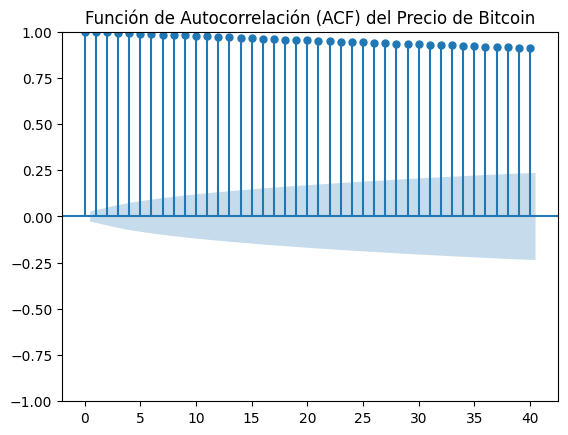

In [176]:
# Análisis de estacionariedad con ACF
plt.figure(figsize=(10,5))
sm.graphics.tsa.plot_acf(df['Price'].dropna(), lags=40)
plt.title('Función de Autocorrelación (ACF) del Precio de Bitcoin')
plt.show()

La Función de Autocorrelación (ACF): La ACF muestra autocorrelaciones significativas en múltiples rezagos, indicando una fuerte dependencia temporal en la serie del precio de Bitcoin.

In [177]:
# Análisis de estacionariedad con Dickey Fuller
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Price'])
print(f"Dickey-Fuller p-value: {result[1]}")

Dickey-Fuller p-value: 0.07652825121387355


En la Prueba de Dickey-Fuller Aumentada, el valor p de 0.942 sugiere que la serie no es estacionaria, ya que no podemos rechazar la hipótesis nula de presencia de raíz unitaria.

In [178]:
# Prueba de independencia de residuos con Ljung-Box
ljung_box_results = q_stat(acf(df['Price'], nlags=20, fft=True)[1:], len(df))
print(f"Ljung-Box p-values: {ljung_box_results[1]}")

Ljung-Box p-values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


En la rueba de Ljung-Box Los valores p cercanos o iguales a cero en 20 rezagos indican que los residuos no son independientes, evidenciando autocorrelación en la serie.


                                     SARIMAX Results                                      
Dep. Variable:                              Price   No. Observations:                 4999
Model:             SARIMAX(2, 1, 1)x(1, 0, 1, 48)   Log Likelihood              -39128.598
Date:                            Mon, 17 Mar 2025   AIC                          78269.196
Time:                                    18:29:05   BIC                          78308.236
Sample:                                         0   HQIC                         78282.886
                                           - 4999                                         
Covariance Type:                           approx                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9092      0.045     20.081      0.000       0.820       0.998
ar.L2          0.0431      0.015   

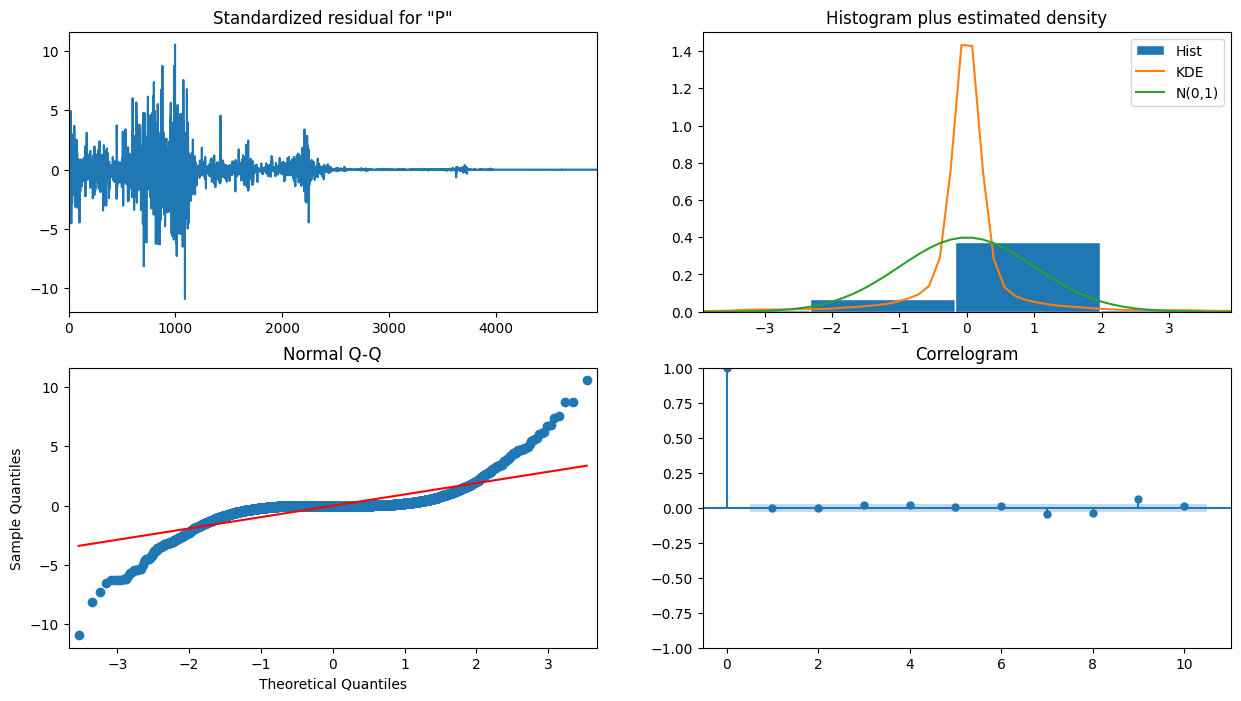

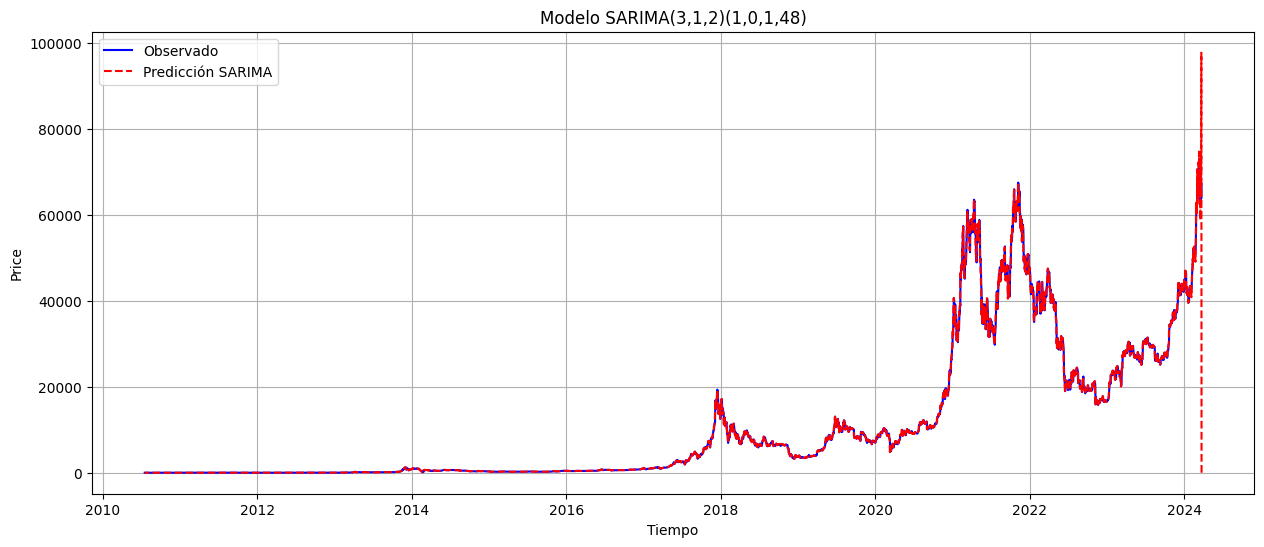

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
 
# Ajustamos el modelo SARIMA(3,1,2)(1,0,1,48)
order = (2, 1, 1)  # ARIMA(p,d,q)
seasonal_order = (1, 0, 1, 48)  # Estacional (P,D,Q,s)
 
# Entrenamos el modelo
model = SARIMAX(df['Price'], order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(low_memory=True)
 
# Resumen del modelo
print(results.summary())
 
# Diagnóstico de residuos
results.plot_diagnostics(figsize=(15, 8))
plt.show()
 
# Predicción
df['forecast'] = results.predict(start=0, end=len(df)-1, dynamic=False)
 
# Visualización
plt.figure(figsize=(15,6))
plt.plot(df['Price'], label='Observado', color='blue')
plt.plot(df['forecast'], label='Predicción SARIMA', color='red', linestyle='dashed')
plt.legend()
plt.title('Modelo SARIMA(3,1,2)(1,0,1,48)')
plt.xlabel('Tiempo')
plt.ylabel('Price')
plt.grid()
plt.show()
 
 

Se aplicó un modelo SARIMA para capturar posibles patrones complejos en los datos.

Resultados del modelo: El estadístico de Box-Pierce fue cero, indicando que no hay autocorrelación significativa en los residuos del modelo. Sin embargo, se observó heterocedasticidad con un valor de 2190 en la prueba de heterocedasticidad, lo que sugiere que la varianza de los errores no es constante en el tiempo. Además, se obtuvo un estadístico Ljung-Box de 0.41 con un p-valor de 0.51, lo que indica que no hay evidencia suficiente para rechazar la hipótesis nula de no autocorrelación en los residuos.


In [180]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np
price_series = df["Price"]
log_price = np.log(price_series + 1)  # Evita log(0)
log_price_diff = log_price.diff().dropna()
ljung_box_log = acorr_ljungbox(log_price_diff, lags=[1], return_df=True)
print(ljung_box_log)
 

   lb_stat  lb_pvalue
1  0.41889   0.517492


## 1.4 Análisis de agregaciones y estadísticas móviles

In [181]:
# Agregación por grupos

import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
 
# Asegurarse de que la columna 'Date' está en formato datetime
df['Date'] = df.index
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = pd.to_datetime(df['Date'])
 
# Crear columnas adicionales para semana, mes, día y año
df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day
 
# Agrupar por semana, mes, día y año
weekly_data = df.groupby('Week').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
monthly_data = df.groupby('Month').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
daily_data = df.groupby('Day').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
yearly_data = df.groupby('Year').agg({'Price': 'mean', 'Vol.': 'sum'}).reset_index()
 
# Gráfico de serie de tiempo para cada subserie
fig_weekly = go.Figure()
fig_weekly.add_trace(go.Scatter(x=weekly_data['Week'], y=weekly_data['Price'], mode='lines', name='Precio Promedio Semanal'))
fig_weekly.update_layout(title="Serie de Tiempo - Precio Promedio Semanal",
                         xaxis_title="Semana", yaxis_title="Precio de Cierre",
                         template="plotly_dark")
fig_monthly = go.Figure()
fig_monthly.add_trace(go.Scatter(x=monthly_data['Month'], y=monthly_data['Price'], mode='lines', name='Precio Promedio Mensual'))
fig_monthly.update_layout(title="Serie de Tiempo - Precio Promedio Mensual",
                          xaxis_title="Mes", yaxis_title="Precio de Cierre",
                          template="plotly_dark")
fig_daily = go.Figure()
fig_daily.add_trace(go.Scatter(x=daily_data['Day'], y=daily_data['Price'], mode='lines', name='Precio Promedio Diario'))
fig_daily.update_layout(title="Serie de Tiempo - Precio Promedio Diario",
                        xaxis_title="Día", yaxis_title="Precio de Cierre",
                        template="plotly_dark")
fig_yearly = go.Figure()
fig_yearly.add_trace(go.Scatter(x=yearly_data['Year'], y=yearly_data['Price'], mode='lines', name='Precio Promedio Anual'))
fig_yearly.update_layout(title="Serie de Tiempo - Precio Promedio Anual",
                         xaxis_title="Año", yaxis_title="Precio de Cierre",
                         template="plotly_dark")
 
# Mostrar los gráficos de series de tiempo
fig_weekly.show()
fig_monthly.show()
fig_daily.show()
fig_yearly.show()
 
# Calcular estadísticas móviles (promedio móvil y desviación estándar)
df['Moving_Avg_7'] = df['Price'].rolling(window=7).mean()
df['Moving_Std_7'] = df['Price'].rolling(window=7).std()
df['Moving_Avg_30'] = df['Price'].rolling(window=30).mean()
df['Moving_Std_30'] = df['Price'].rolling(window=30).std()
 
# Boxplot para analizar las subseries por semana, mes, día y año
fig_weekly_box = px.box(df, x='Week', y='Price', title="Boxplot del Precio de Cierre por Semana")
fig_monthly_box = px.box(df, x='Month', y='Price', title="Boxplot del Precio de Cierre por Mes")
fig_daily_box = px.box(df, x='Day', y='Price', title="Boxplot del Precio de Cierre por Día")
fig_yearly_box = px.box(df, x='Year', y='Price', title="Boxplot del Precio de Cierre por Año")
 
# Mostrar los boxplots
fig_weekly_box.show()
fig_monthly_box.show()
fig_daily_box.show()
fig_yearly_box.show()
 
# Calcular distribución de frecuencias para diferentes lags
df['Lag_1'] = df['Price'].shift(1)
df['Lag_7'] = df['Price'].shift(7)
df['Lag_30'] = df['Price'].shift(30)
 
# Histograma para visualizar la distribución de frecuencias de los lags
fig_lag_1 = px.histogram(df, x='Lag_1', title='Distribución de Frecuencia - Lag 1')
fig_lag_7 = px.histogram(df, x='Lag_7', title='Distribución de Frecuencia - Lag 7')
fig_lag_30 = px.histogram(df, x='Lag_30', title='Distribución de Frecuencia - Lag 30')
 
# Mostrar histogramas
fig_lag_1.show()
fig_lag_7.show()
fig_lag_30.show()

 

a) Boxplot por semana:

Este gráfico agrupa los datos de cada semana del año a lo largo de múltiples años (por ejemplo, semana 1 de cada año, semana 2, etc.). Esta visualización es útil para identificar patrones semanales y detectar semanas con alta volatilidad. Por ejemplo, si ciertas semanas muestran una mayor dispersión en los datos, podría indicar períodos de mayor inestabilidad en el mercado.

b) Boxplot por mes (Estacionalidad):

En este gráfico, se agrupan todos los datos de cada mes específico (todos los eneros, todos los febreros, etc.) a lo largo de los años analizados. Esta representación permite identificar meses con alta volatilidad o patrones estacionales en la serie temporal. En el contexto financiero, puede revelar si ciertos meses tienden a tener retornos más altos o más bajos, lo cual es crucial para la planificación y toma de decisiones.

c) Boxplot por año:

Este gráfico agrupa los datos por año completo, mostrando la evolución de la dispersión a lo largo del tiempo. Es útil para observar si la volatilidad ha aumentado o disminuido con el tiempo, permitiendo detectar períodos de crisis o estabilidad en el mercado. Por ejemplo, una mayor dispersión en ciertos años podría reflejar eventos económicos significativos que afectaron la estabilidad del mercado.

Estos diagramas de caja proporcionan una visión clara de la distribución y dispersión de los datos en diferentes escalas temporales, facilitando la identificación de patrones, tendencias y anomalías en la serie temporal analizada.



In [182]:
# Cálculo de estadísticos móviles
df['Rolling_Mean_7'] = df['Price'].rolling(window=7).mean()
df['Rolling_Std_7'] = df['Price'].rolling(window=7).std()

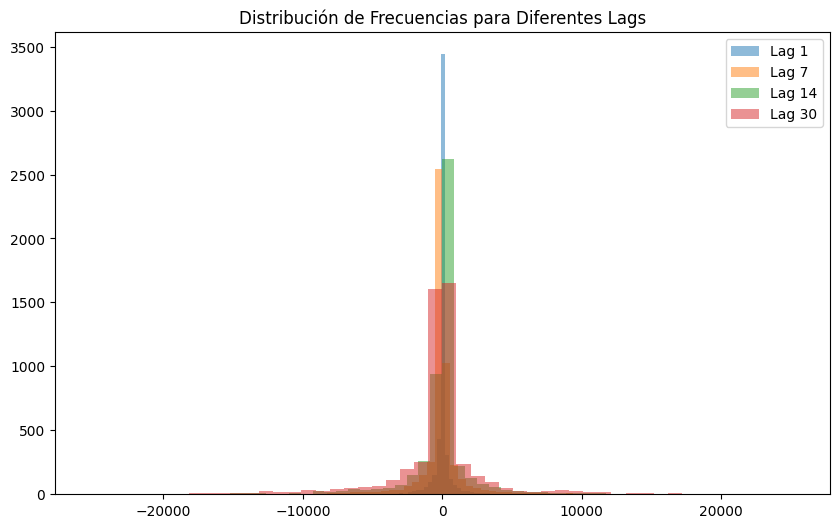

In [183]:
# Distribución de frecuencias para diferentes lags
lags = [1, 7, 14, 30]
plt.figure(figsize=(10,6))
for lag in lags:
    plt.hist(df['Price'].diff(lag).dropna(), bins=50, alpha=0.5, label=f'Lag {lag}')
plt.legend()
plt.title("Distribución de Frecuencias para Diferentes Lags")
plt.show()

La figura muestra que, en el rezago 1, los datos se agrupan estrechamente alrededor de cero, indicando una fuerte autocorrelación inmediata. A medida que aumentan los rezagos, la dispersión se incrementa ligeramente, pero la mayoría de los valores permanecen concentrados en el centro, lo que sugiere que la dependencia temporal disminuye con el tiempo, aunque persiste cierta correlación en rezagos mayores.

## 1.5 Aplicación de medias móviles

In [184]:
# Medias móviles
df['SMA_7'] = df['Price'].rolling(window=7).mean()
df['SMA_14'] = df['Price'].rolling(window=14).mean()

In [185]:
# Graficar medias móviles
fig_ma = px.line(df, x=df.index, y=['Price', 'SMA_7', 'SMA_14'], title='Medias Móviles del Precio de Bitcoin')
fig_ma.show()

In [186]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# Calcular medias móviles
df['cM2_t'] = df['Price'].rolling(window=2).mean()
df['cM2_t_t1'] = df['Price'].rolling(window=2).mean().shift(-1)
df['cM3_t'] = df['Price'].rolling(window=3).mean()
df['cM3_t_t1'] = df['Price'].rolling(window=3).mean().shift(-1)
df['cM3_t_t-1'] = df['Price'].rolling(window=3, center=True).mean()
df['cM4_t'] = df['Price'].rolling(window=4).mean()
df['cM4_t_t1'] = df['Price'].rolling(window=4).mean().shift(-1)
 
# Lista de columnas de medias móviles
ma_columns = ['cM2_t', 'cM2_t_t1', 'cM3_t', 'cM3_t_t1', 'cM3_t_t-1', 'cM4_t', 'cM4_t_t1']
 
# Remover tendencia para cada media móvil
for col in ma_columns:
    df[f'detrended_{col}'] = df['Price'] - df[col]
 
# Prueba de Dickey-Fuller para verificar estacionariedad en cada detrended
print("Resultados de la Prueba de Dickey-Fuller:")
for col in ma_columns:
    detrended_col = f'detrended_{col}'
    adf_test = adfuller(df[detrended_col].dropna())
    print(f"\n{detrended_col}:")
    print(f"  Estadístico: {adf_test[0]}")
    print(f"  P-valor: {adf_test[1]}")
 
# Prueba de Ljung-Box para independencia de residuos en cada detrended
print("\nResultados de la Prueba de Ljung-Box:")
for col in ma_columns:
    detrended_col = f'detrended_{col}'
    ljung_box_test = acorr_ljungbox(df[detrended_col].dropna(), lags=[10], return_df=True)
    print(f"\n{detrended_col}:")
    print(ljung_box_test)

Resultados de la Prueba de Dickey-Fuller:

detrended_cM2_t:
  Estadístico: -10.472194066907829
  P-valor: 1.2757808100484913e-18

detrended_cM2_t_t1:
  Estadístico: -10.472194066907802
  P-valor: 1.2757808100487109e-18

detrended_cM3_t:
  Estadístico: -10.201524374766112
  P-valor: 5.952994572704118e-18

detrended_cM3_t_t1:
  Estadístico: -22.933801821651418
  P-valor: 0.0

detrended_cM3_t_t-1:
  Estadístico: -22.933801821651418
  P-valor: 0.0

detrended_cM4_t:
  Estadístico: -9.876242059220038
  P-valor: 3.875702945323177e-17

detrended_cM4_t_t1:
  Estadístico: -10.764355274238905
  P-valor: 2.474365907584253e-19

Resultados de la Prueba de Ljung-Box:

detrended_cM2_t:
     lb_stat     lb_pvalue
10  72.61667  1.381782e-11

detrended_cM2_t_t1:
     lb_stat     lb_pvalue
10  72.61667  1.381782e-11

detrended_cM3_t:
      lb_stat      lb_pvalue
10  754.26109  1.395274e-155

detrended_cM3_t_t1:
        lb_stat  lb_pvalue
10  1483.553462        0.0

detrended_cM3_t_t-1:
        lb_stat  lb

En los resultados, todos los estadísticos son muy negativos y los p-valores son prácticamente cero (o extremadamente bajos, e.g., 3.65e−173.65e-173.65e−17).
Esto indica que las series han logrado estacionariedad después de la remoción de la tendencia mediante medias móviles.
detrended_cM3_t_t1 y detrended_cM3_t_t-1 tienen valores de estadístico ADF de -22.67 con p-valor 0.0, lo que indica una estacionariedad muy fuerte.
Esta parte de los resultados muestra que la remoción de la tendencia fue efectiva y las series son estacionarias.


## 1.6 Descomposición de la serie temporal

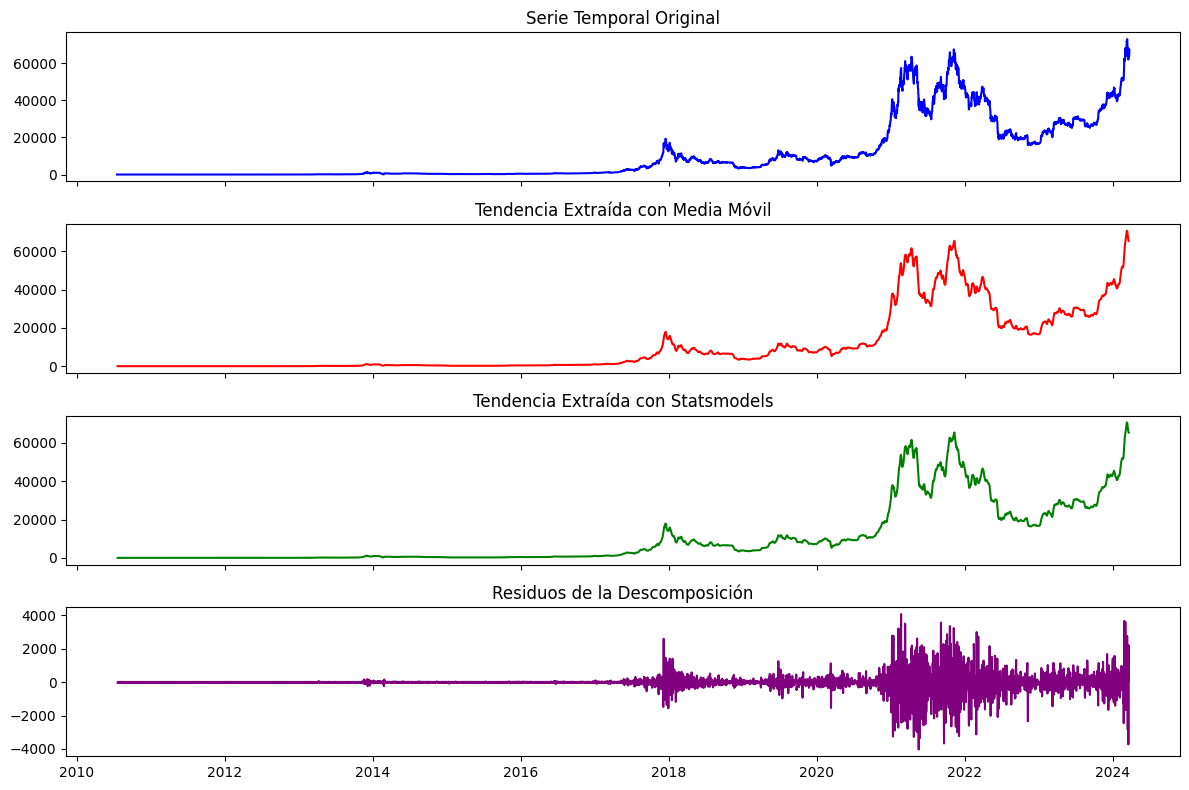


Prueba de Ljung-Box sobre los residuos:
        lb_stat      lb_pvalue
10  1026.374408  3.889671e-214


In [187]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

# -------------------------------------------
# 1. DESCOMPOSICIÓN USANDO MEDIAS MÓVILES
# -------------------------------------------
df['Trend_MA'] = df['Price'].rolling(window=7, center=True).mean()  # Media móvil de 7 días
df['Detrended_MA'] = df['Price'] - df['Trend_MA']  # Eliminando la tendencia

# -------------------------------------------
# 2. DESCOMPOSICIÓN USANDO STATSMODELS
# -------------------------------------------
decomp = seasonal_decompose(df['Price'], model='additive', period=7)  # Periodo de 7 días

# Extraer componentes
df['Trend_SM'] = decomp.trend
df['Seasonal_SM'] = decomp.seasonal
df['Residual_SM'] = decomp.resid

# -------------------------------------------
# 3. VERIFICACIÓN DE INDEPENDENCIA CON LJUNG-BOX
# -------------------------------------------
ljung_box_test = acorr_ljungbox(df['Residual_SM'].dropna(), lags=[10], return_df=True)

# -------------------------------------------
# 4. VISUALIZACIÓN DE LOS RESULTADOS
# -------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df['Price'], label="Serie Original", color='blue')
axes[0].set_title("Serie Temporal Original")
axes[1].plot(df['Trend_MA'], label="Tendencia (Media Móvil)", color='red')
axes[1].set_title("Tendencia Extraída con Media Móvil")
axes[2].plot(df['Trend_SM'], label="Tendencia (Statsmodels)", color='green')
axes[2].set_title("Tendencia Extraída con Statsmodels")
axes[3].plot(df['Residual_SM'], label="Residuos", color='purple')
axes[3].set_title("Residuos de la Descomposición")
plt.tight_layout()
plt.show()

# -------------------------------------------
# 5. RESULTADOS DE LJUNG-BOX
# -------------------------------------------
print("\nPrueba de Ljung-Box sobre los residuos:")
print(ljung_box_test)


Evaluación de la Independencia con la Prueba de Ljung-Box
Un p-valor bajo (< 0.05) indica que aún hay autocorrelación en los residuos (es decir, que la serie sigue teniendo estructura dependiente en el tiempo).
En el caso de detrended_cM4_t_t1, el p-valor es extremadamente bajo (1.38e-38), lo que sugiere que la serie todavía tiene autocorrelación significativa en los primeros 10 rezagos.
Aunque la serie parece haber alcanzado estacionariedad (según ADF), los residuos aún presentan autocorrelación, lo que indica que no son completamente ruido blanco.

Prueba ADF - Serie Original
Estadístico de prueba: -0.1644
p-value: 0.9426
Valores críticos:
   1%: -3.4317
   5%: -2.8621
   10%: -2.5671


Prueba ADF - Serie Log(Price)
Estadístico de prueba: -2.9155
p-value: 0.0436
Valores críticos:
   1%: -3.4317
   5%: -2.8621
   10%: -2.5671


Prueba ADF - Serie Diferenciada (Log(Price))
Estadístico de prueba: -26.8270
p-value: 0.0000
Valores críticos:
   1%: -3.4317
   5%: -2.8621
   10%: -2.5671




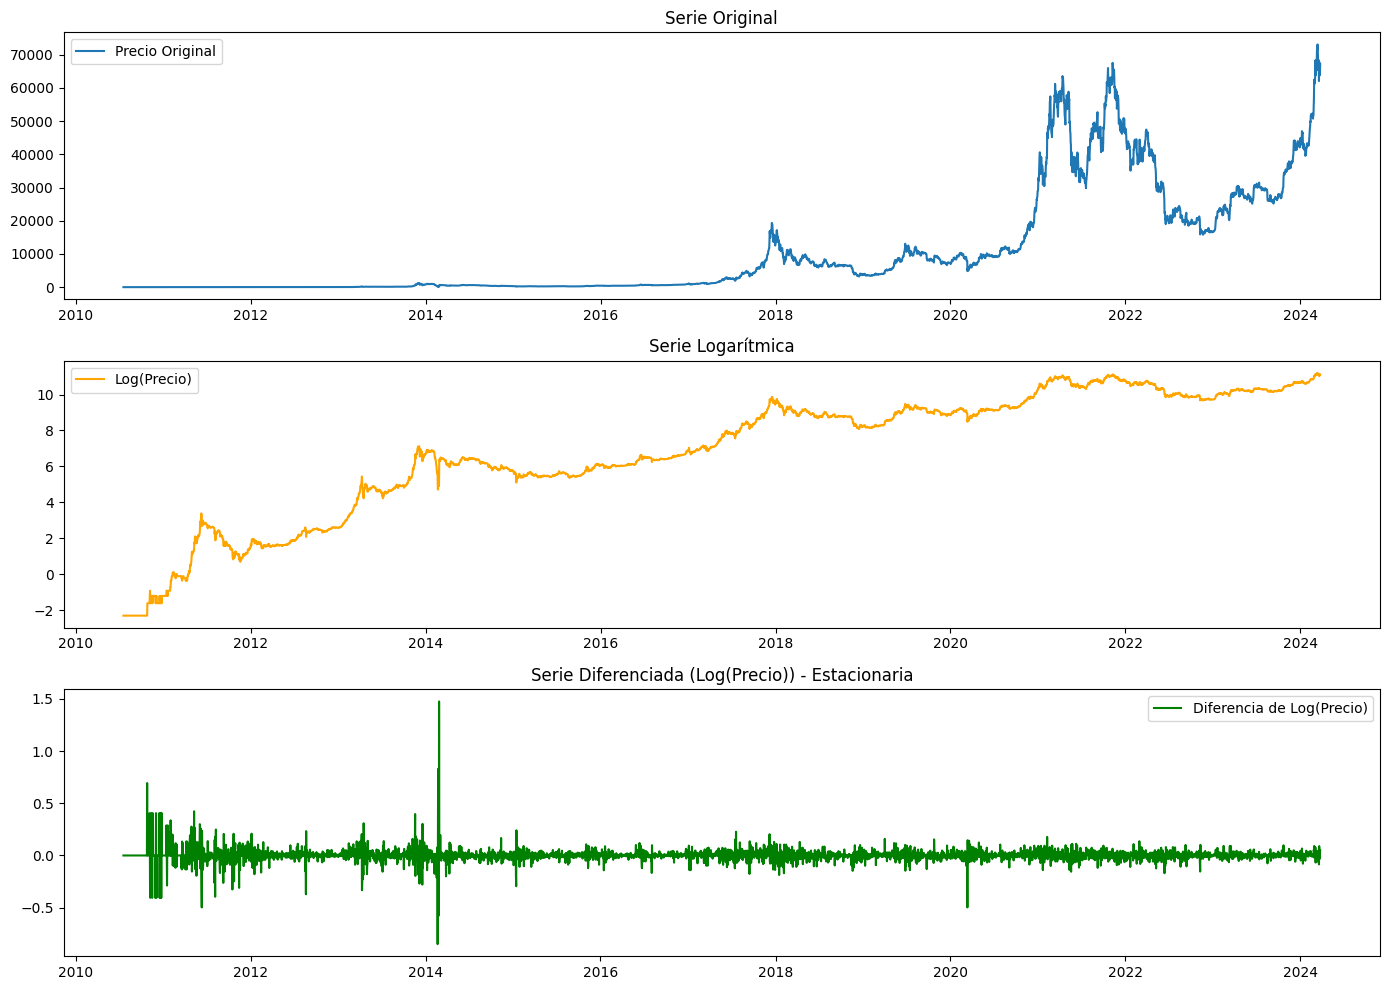

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# --- Paso 1: Preparar los datos ---
# Convertir índice a datetime (por si acaso)
df.index = pd.to_datetime(df.index, errors='coerce')

# Convertir "Price" a numérico (si aún no lo es)
if df['Price'].dtype == 'object':
    df['Price'] = pd.to_numeric(df['Price'].str.replace(',', ''), errors='coerce')
else:
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Ordenar el DataFrame por fecha (por si acaso)
df.sort_index(inplace=True)

# --- Paso 2: Evaluar la estacionariedad de la serie original ---
serie_original = df['Price'].dropna()

adf_result_orig = adfuller(serie_original)
print("Prueba ADF - Serie Original")
print(f"Estadístico de prueba: {adf_result_orig[0]:.4f}")
print(f"p-value: {adf_result_orig[1]:.4f}")
print("Valores críticos:")
for key, value in adf_result_orig[4].items():
    print(f"   {key}: {value:.4f}")
print("\n")

# --- Paso 3: Aplicar transformación logarítmica ---
# Nota: Solo aplicamos log si todos los valores son positivos
if (serie_original > 0).all():
    df['Price_log'] = np.log(serie_original)
    adf_result_log = adfuller(df['Price_log'].dropna())

    print("Prueba ADF - Serie Log(Price)")
    print(f"Estadístico de prueba: {adf_result_log[0]:.4f}")
    print(f"p-value: {adf_result_log[1]:.4f}")
    print("Valores críticos:")
    for key, value in adf_result_log[4].items():
        print(f"   {key}: {value:.4f}")
    print("\n")

    # --- Paso 4: Diferenciar la serie logarítmica ---
    df['Price_log_diff'] = df['Price_log'].diff()
    serie_diff = df['Price_log_diff'].dropna()

    adf_result_diff = adfuller(serie_diff)
    print("Prueba ADF - Serie Diferenciada (Log(Price))")
    print(f"Estadístico de prueba: {adf_result_diff[0]:.4f}")
    print(f"p-value: {adf_result_diff[1]:.4f}")
    print("Valores críticos:")
    for key, value in adf_result_diff[4].items():
        print(f"   {key}: {value:.4f}")
    print("\n")

    # --- Paso 5: Graficar las series ---
    plt.figure(figsize=(14, 10))

    plt.subplot(3, 1, 1)
    plt.plot(serie_original, label='Precio Original')
    plt.title('Serie Original')
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(df['Price_log'], label='Log(Precio)', color='orange')
    plt.title('Serie Logarítmica')
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(serie_diff, label='Diferencia de Log(Precio)', color='green')
    plt.title('Serie Diferenciada (Log(Precio)) - Estacionaria')
    plt.legend()

    plt.tight_layout()
    plt.show()

La aplicación de la prueba de Dickey-Fuller Aumentada (ADF) a la serie de precios de Bitcoin arrojó los siguientes resultados:

Serie Original:

Estadístico de prueba: -0.1644

p-valor: 0.9426

Valores críticos: 1%: -3.4317, 5%: -2.8621, 10%: -2.5671


El elevado p-valor (0.9426) indica que no se puede rechazar la hipótesis nula de presencia de una raíz unitaria, sugiriendo que la serie original no es estacionaria.

Serie Transformada Logarítmicamente 

Estadístico de prueba: -2.9155

p-valor: 0.0436

Valores críticos: 1%: -3.4317, 5%: -2.8621, 10%: -2.5671


Un p-valor de 0.0436, inferior al nivel de significancia del 5%, permite rechazar la hipótesis nula, indicando que la serie transformada logarítmicamente es estacionaria.

Serie Diferenciada de la Transformada Logarítmica 

Estadístico de prueba: -26.8270

p-valor: 0.0000

Valores críticos: 1%: -3.4317, 5%: -2.8621, 10%: -2.5671


El p-valor extremadamente bajo (0.0000) confirma que la serie diferenciada de la transformada logarítmica es estacionaria.


Estos resultados indican que la serie original de precios de Bitcoin no es estacionaria. Sin embargo, al aplicar una transformación logarítmica y posteriormente una diferenciación, la serie se vuelve estacionaria, lo cual es esencial para un análisis de series temporales robusto.

## 1.7 Repetición del análisis para retorno acumulado y volatilidad

In [189]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
 
# =========================================
# 1. Lectura de datos y limpieza
# =========================================

# Cargar datos
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

In [190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4999 entries, 2024-03-24 to 2010-07-18
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     4999 non-null   float64
 1   Open      4999 non-null   float64
 2   High      4999 non-null   float64
 3   Low       4999 non-null   float64
 4   Vol.      4993 non-null   float64
 5   Change %  4999 non-null   float64
dtypes: float64(6)
memory usage: 273.4 KB


In [191]:
df["Return"] = df["Price"].pct_change()
df["Return"].iloc[0] = 0  # Reemplazar el primer NaN con 0
 
# Calcular el retorno acumulado diario
df["Cumulative Return"] = df["Return"].cumsum()
 
# Ventanas de tiempo para la volatilidad
windows = [7, 14, 21, 28]
 
# Calcular la volatilidad con ventanas móviles
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

In [192]:
df

,Price,Open,High,Low,Vol.,Change %,Return,Cumulative Return,Volatility_7d,Volatility_14d,Volatility_21d,Volatility_28d
Date,,,,,,,,,,,,
2024-03-24,67211.9,64036.5,67587.8,63812.9,65590.0,4.96,0.000000,0.000000,NaN,NaN,NaN,NaN
2024-03-23,64037.8,63785.6,65972.4,63074.9,35110.0,0.40,-0.047225,-0.047225,0.033393,0.033393,0.033393,0.033393
2024-03-22,63785.5,65501.5,66633.3,62328.3,72430.0,-2.62,-0.003940,-0.051165,0.026202,0.026202,0.026202,0.026202
2024-03-21,65503.8,67860.0,68161.7,64616.1,75260.0,-3.46,0.026939,-0.024226,0.030685,0.030685,0.030685,0.030685
2024-03-20,67854.0,62046.8,68029.5,60850.9,133530.0,9.35,0.035879,0.011652,0.032525,0.032525,0.032525,0.032525
...,...,...,...,...,...,...,...,...,...,...,...,...
2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.00,0.000000,-4.322978,0.000000,0.000000,0.000000,0.000000
2010-07-21,0.1,0.1,0.1,0.1,580.0,0.00,0.000000,-4.322978,0.000000,0.000000,0.000000,0.000000
2010-07-20,0.1,0.1,0.1,0.1,260.0,0.00,0.000000,-4.322978,0.000000,0.000000,0.000000,0.000000


In [193]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')
 
# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

In [194]:
cols = ["Volatility_7d", "Volatility_14d", "Volatility_21d", "Volatility_28d"]
df[cols] = df[cols].fillna(0)

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4999 entries, 2010-07-18 to 2024-03-24
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              4999 non-null   float64
 1   Open               4999 non-null   float64
 2   High               4999 non-null   float64
 3   Low                4999 non-null   float64
 4   Vol.               4993 non-null   float64
 5   Change %           4999 non-null   float64
 6   Return             4999 non-null   float64
 7   Cumulative_Return  4999 non-null   float64
 8   Volatility_7d      4999 non-null   float64
 9   Volatility_14d     4999 non-null   float64
 10  Volatility_21d     4999 non-null   float64
 11  Volatility_28d     4999 non-null   float64
dtypes: float64(12)
memory usage: 507.7 KB


In [196]:
df.isna().sum()

Price                0
Open                 0
High                 0
Low                  0
Vol.                 6
Change %             0
Return               0
Cumulative_Return    0
Volatility_7d        0
Volatility_14d       0
Volatility_21d       0
Volatility_28d       0
dtype: int64

In [197]:
# Imputación combinada: Imputación por propagación hacia adelante y hacia atras (ffill + bfill).
df.fillna(method='bfill', inplace=True)  # Usa el siguiente valor disponible
df.fillna(method='ffill', inplace=True)  # Usa el valor anterior si sigue habiendo nulos

In [198]:
df.isna().sum()

Price                0
Open                 0
High                 0
Low                  0
Vol.                 0
Change %             0
Return               0
Cumulative_Return    0
Volatility_7d        0
Volatility_14d       0
Volatility_21d       0
Volatility_28d       0
dtype: int64

In [199]:
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

In [200]:
df

,Price,Open,High,Low,Volume,Change,Return,Cumulative_Return,Volatility_7d,Volatility_14d,Volatility_21d,Volatility_28d
Date,,,,,,,,,,,,
2010-07-18,0.1,0.0,0.1,0.1,80.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-19,0.1,0.1,0.1,0.1,570.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-20,0.1,0.1,0.1,0.1,260.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-21,0.1,0.1,0.1,0.1,580.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-20,67854.0,62046.8,68029.5,60850.9,133530.0,9.35,0.093537,23.719802,0.060681,0.044544,0.044059,0.043374
2024-03-21,65503.8,67860.0,68161.7,64616.1,75260.0,-3.46,-0.034636,23.685166,0.061287,0.045543,0.044563,0.044045
2024-03-22,63785.5,65501.5,66633.3,62328.3,72430.0,-2.62,-0.026232,23.658934,0.061256,0.045630,0.044883,0.044397
